In [29]:
import numpy as np
from monodromy.render import _plot_coverage_set
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import (
    CXGate,
    RZXGate,
    UGate,
    UnitaryGate,
    XXPlusYYGate,
    iSwapGate,
    SwapGate,
)
from qiskit.circuit.random import random_circuit
from qiskit.quantum_info import Operator, average_gate_fidelity
from qiskit.quantum_info.random import random_unitary
from qiskit.transpiler import (
    InstructionProperties,
    PassManager,
    Target,
    generate_preset_pass_manager,
)
from qiskit.transpiler.passes import Optimize1qGatesDecomposition
from tqdm import tqdm
from weylchamber import c1c2c3

from gulps.gulps_decomposer import GulpsDecomposer
from gulps.synthesis_pass import GulpsDecompositionPass
from gulps.utils.invariants import GateInvariants
from gulps.utils.visualize import render_path
from monodromy.haar import expected_cost

# from gulps.synthesis_plugin import GulpsSynthesisPlugin

In [30]:
from gulps.utils.logging_config import logger

logger.setLevel("INFO")
# logger.setLevel("DEBUG")

In [31]:
def fsim(theta, phi):
    _fsim = QuantumCircuit(2, name="fsim")
    _fsim.append(XXPlusYYGate(2 * theta), [0, 1])
    _fsim.cp(phi, 0, 1)
    return _fsim.to_gate()


# comment out what you don't want or add your own
isa = [
    # (CXGate(), 1.0, "cx"),
    # (CXGate().power(1 / 2), 1 / 2, "sqrt2cx"),
    # (iSwapGate(), 1.0, "iswap"),
    # (iSwapGate().power(1 / 2), 1 / 2, "sqrt2iswap"),
    # (iSwapGate().power(1 / 3), 1 / 3, "sqrt3iswap"),
    (iSwapGate().power(1 / 4), 1 / 4, "sqrt4iswap"),
    # (fsim(np.pi / 2, np.pi / 6).power(1.0), 1.0, "fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 2), 1 / 2, "sqrt2fsim"),
    # (fsim(np.pi / 2, np.pi / 6).power(1 / 3), 1 / 3, "sqrt3fsim"),
    # (SwapGate(), 0.0, "swap"),
]
gate_set, costs, names = zip(*isa)
decomposer = GulpsDecomposer(gate_set=gate_set, costs=costs, names=names)

In [32]:
# warmstart both the easy and hard
# use a seed that calls both
u = random_unitary(4, seed=9)
v = Operator(decomposer._run(u))

[gulps.utils.recover_equiv] WARNING: Cannot recover local equivalence; Weyl differences [7.88961257e-04 7.87227188e-04 1.73442736e-06]. Proceeding with best effort.
[gulps.utils.recover_equiv] WARNING: Cannot recover local equivalence; Weyl differences [7.84505492e-04 7.44646316e-04 3.98586541e-05]. Proceeding with best effort.


In [33]:
N = 1_000
fidelities = []
all_timings = []
for idx in tqdm(range(N)):
    u = random_unitary(4, seed=idx)
    v = Operator(decomposer(u))
    fid = average_gate_fidelity(u, v)
    fidelities.append(fid)
    timing = decomposer.last_timing
    all_timings.append(timing)

    if fid < 1 - 1e-6:
        print(f"Unitary {idx} fidelity is low: {fid:.8f}")
        print("Canonical invariants:")
        print("U:", c1c2c3(u))
        print("V:", c1c2c3(v))
        print("\n")
        continue

# Summary statistics
fidelities = np.array(fidelities)
print(f"\nSummary across {len(fidelities)} samples:")
print(f"  Median fidelity: {np.median(fidelities)}")
print(f"  Mean fidelity:   {np.mean(fidelities)}")
print(f"  Minimum fidelity:{np.min(fidelities)}")

  0%|          | 0/1000 [00:00<?, ?it/s]

  1%|          | 9/1000 [00:00<01:55,  8.56it/s][gulps.utils.recover_equiv] WARNING: Cannot recover local equivalence; Weyl differences [7.88961257e-04 7.87227188e-04 1.73442736e-06]. Proceeding with best effort.
[gulps.utils.recover_equiv] WARNING: Cannot recover local equivalence; Weyl differences [7.84505492e-04 7.44646316e-04 3.98586541e-05]. Proceeding with best effort.
 26%|██▋       | 264/1000 [00:28<01:13,  9.98it/s][gulps.utils.recover_equiv] WARNING: Cannot recover local equivalence; Weyl differences [1.09284704e-03 1.08951847e-03 3.33341228e-06]. Proceeding with best effort.
[gulps.utils.recover_equiv] WARNING: Cannot recover local equivalence; Weyl differences [1.04995213e-03 1.00445998e-03 5.21538815e-05]. Proceeding with best effort.
 27%|██▋       | 266/1000 [00:28<01:53,  6.45it/s]

Unitary 265 fidelity is low: 0.99999831
Canonical invariants:
U: (np.float64(0.46813676), np.float64(0.40174391), np.float64(0.04707233))
V: (np.float64(0.46746834), np.float64(0.40238337), np.float64(0.04710553))




 38%|███▊      | 385/1000 [00:39<00:38, 15.80it/s][gulps.utils.recover_equiv] WARNING: Cannot recover local equivalence; Weyl differences [9.58795974e-04 9.55197754e-04 3.60952546e-06]. Proceeding with best effort.
[gulps.utils.recover_equiv] WARNING: Cannot recover local equivalence; Weyl differences [9.21092419e-04 8.70531777e-04 2.65980148e-05]. Proceeding with best effort.
 39%|███▊      | 387/1000 [00:40<01:22,  7.44it/s]

Unitary 386 fidelity is low: 0.99999871
Canonical invariants:
U: (np.float64(0.48799621), np.float64(0.40127098), np.float64(0.04879876))
V: (np.float64(0.48858259), np.float64(0.40071678), np.float64(0.04878183))




 41%|████      | 410/1000 [00:42<00:38, 15.25it/s][gulps.utils.recover_equiv] WARNING: Cannot recover local equivalence; Weyl differences [6.75421602e-04 6.73642528e-04 1.84449415e-06]. Proceeding with best effort.
[gulps.utils.recover_equiv] WARNING: Cannot recover local equivalence; Weyl differences [6.68602609e-04 6.55395162e-04 8.19925176e-06]. Proceeding with best effort.
 86%|████████▌ | 860/1000 [01:27<00:11, 12.09it/s][gulps.utils.recover_equiv] WARNING: Cannot recover local equivalence; Weyl differences [6.18093364e-04 6.16952795e-04 1.14487803e-06]. Proceeding with best effort.
[gulps.utils.recover_equiv] WARNING: Cannot recover local equivalence; Weyl differences [5.54157762e-04 5.30534458e-04 2.36026016e-05]. Proceeding with best effort.
 89%|████████▉ | 890/1000 [01:31<00:09, 11.05it/s][gulps.utils.recover_equiv] WARNING: Cannot recover local equivalence; Weyl differences [1.72585955e-03 1.72059960e-03 5.42638837e-06]. Proceeding with best effort.
[gulps.utils.recover_equi

Unitary 891 fidelity is low: 0.99999554
Canonical invariants:
U: (np.float64(0.55135426), np.float64(0.40068177), np.float64(0.05023542))
V: (np.float64(0.55244022), np.float64(0.40171908), np.float64(0.05028397))




100%|██████████| 1000/1000 [01:44<00:00,  9.59it/s]


Summary across 1000 samples:
  Median fidelity: 0.9999999999999922
  Mean fidelity:   0.9999999854694058
  Minimum fidelity:0.9999955435050852


In [34]:
# what index gave the maximum duration on numerics
max_timing_idx = np.argmax([t["numeric"] for t in all_timings])
print(f"Maximum timing index: {max_timing_idx}")

Maximum timing index: 162


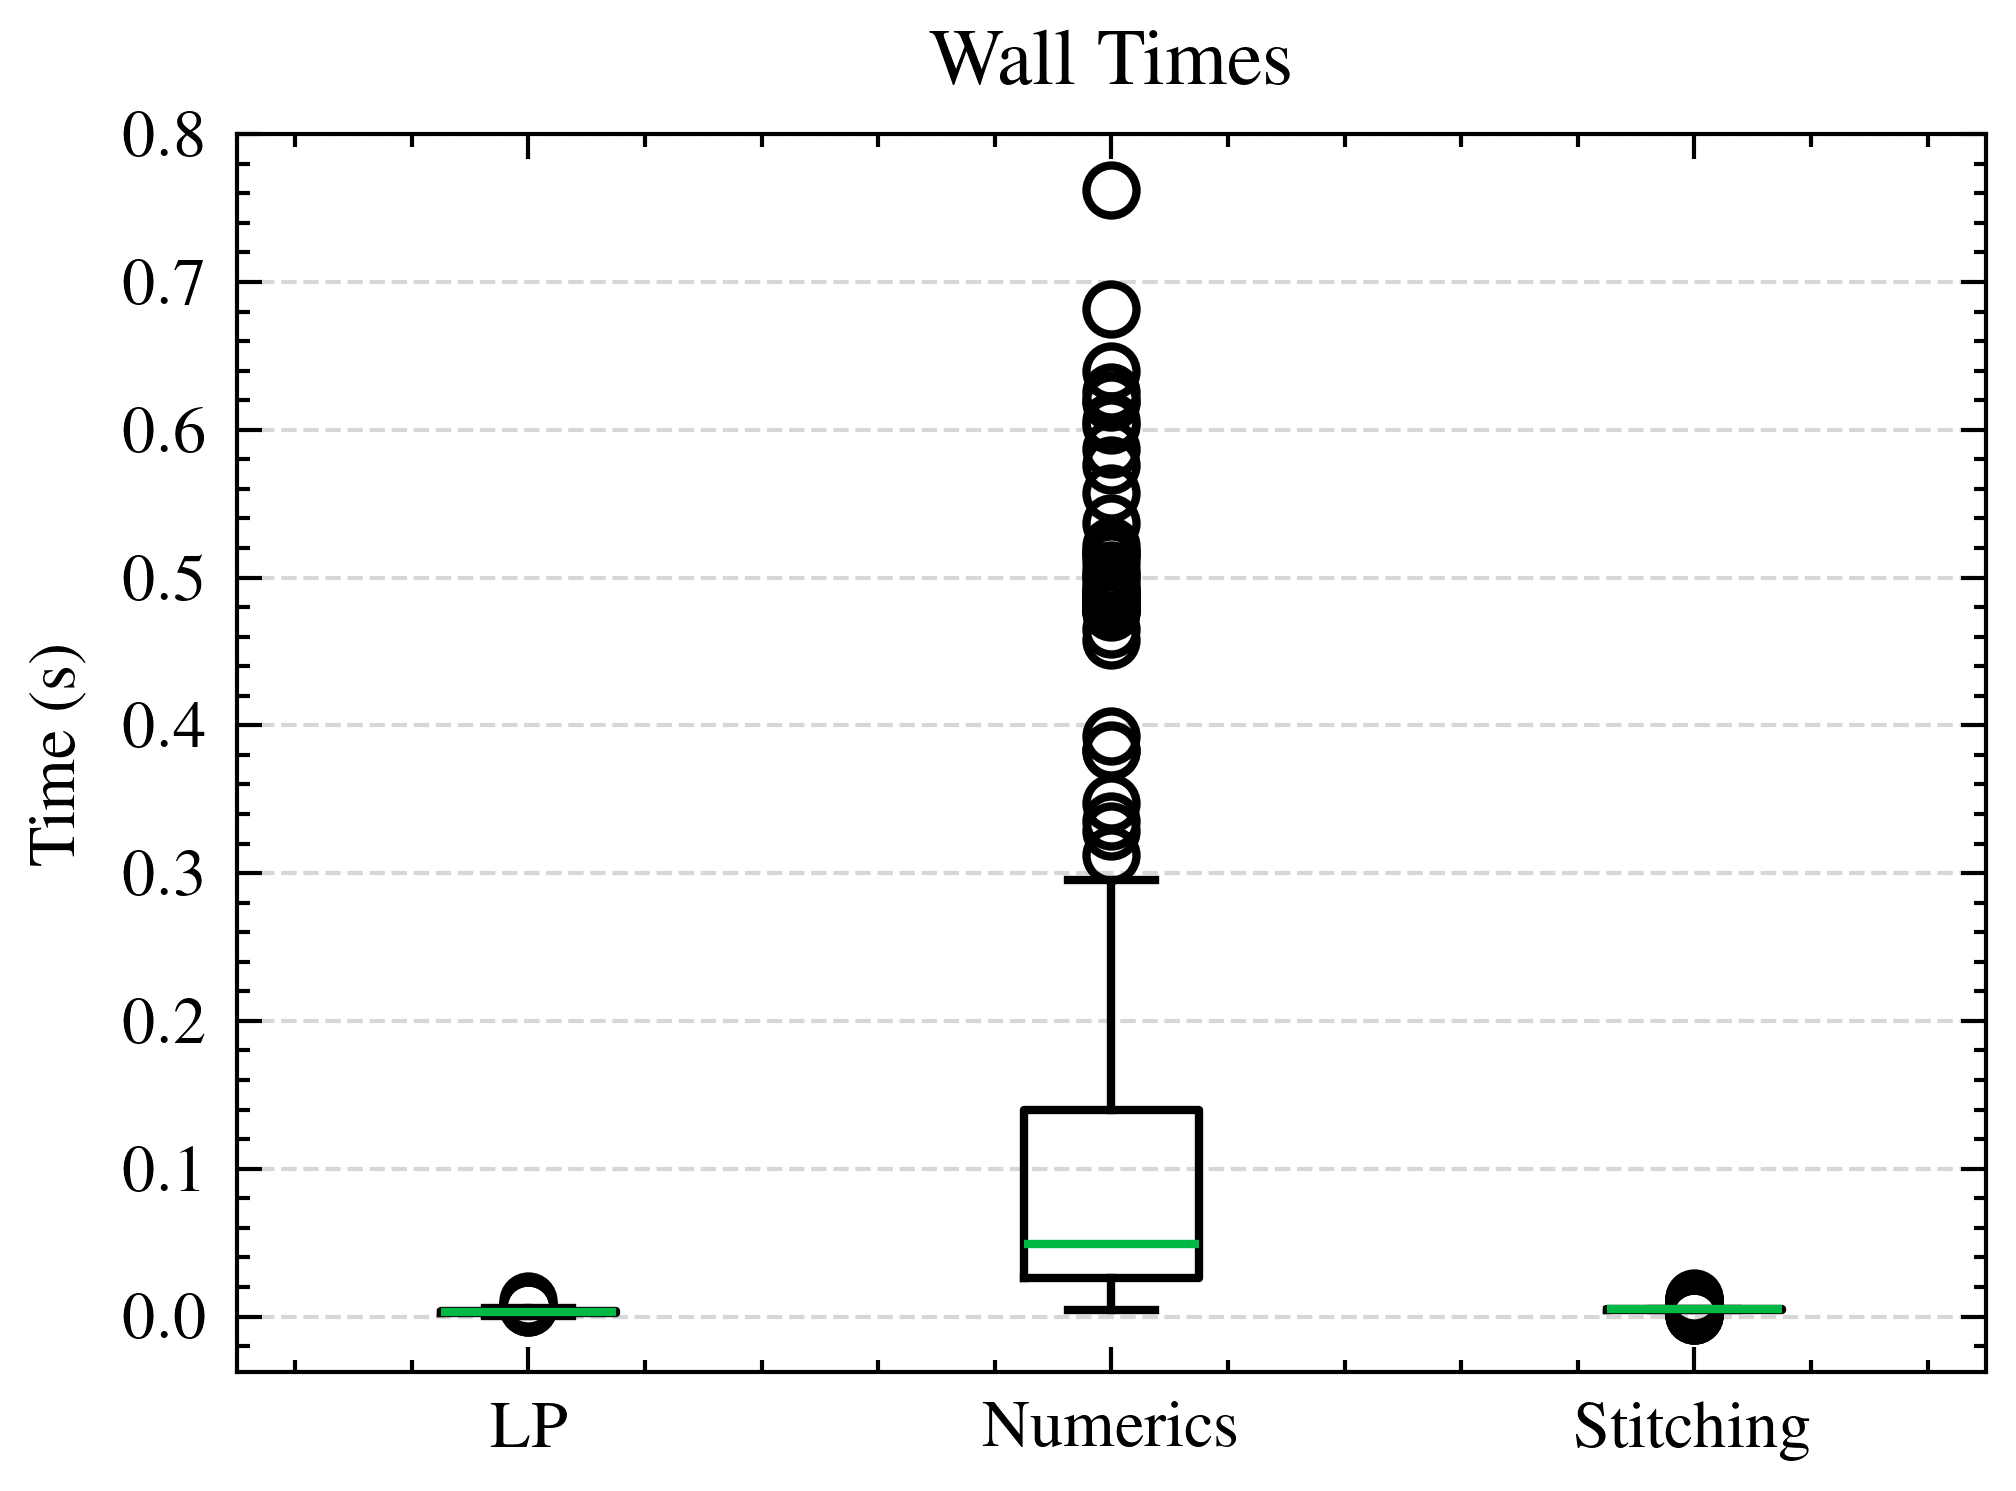

In [35]:
import scienceplots
import lovelyplots

import matplotlib.pyplot as plt
import numpy as np

# Convert list of dicts to lists of values
lp_times = [d["lp"] for d in all_timings]
numeric_times = [d["numeric"] for d in all_timings]
stitch_times = [d["stitch"] for d in all_timings]

# Prepare data for boxplot
data = [lp_times, numeric_times, stitch_times]
labels = ["LP", "Numerics", "Stitching"]
with plt.style.context(["ieee", "science", "use_mathtext"]):
    plt.boxplot(data, tick_labels=labels)
    plt.ylabel("Time (s)")
    plt.title("Wall Times")
    plt.grid(True, axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

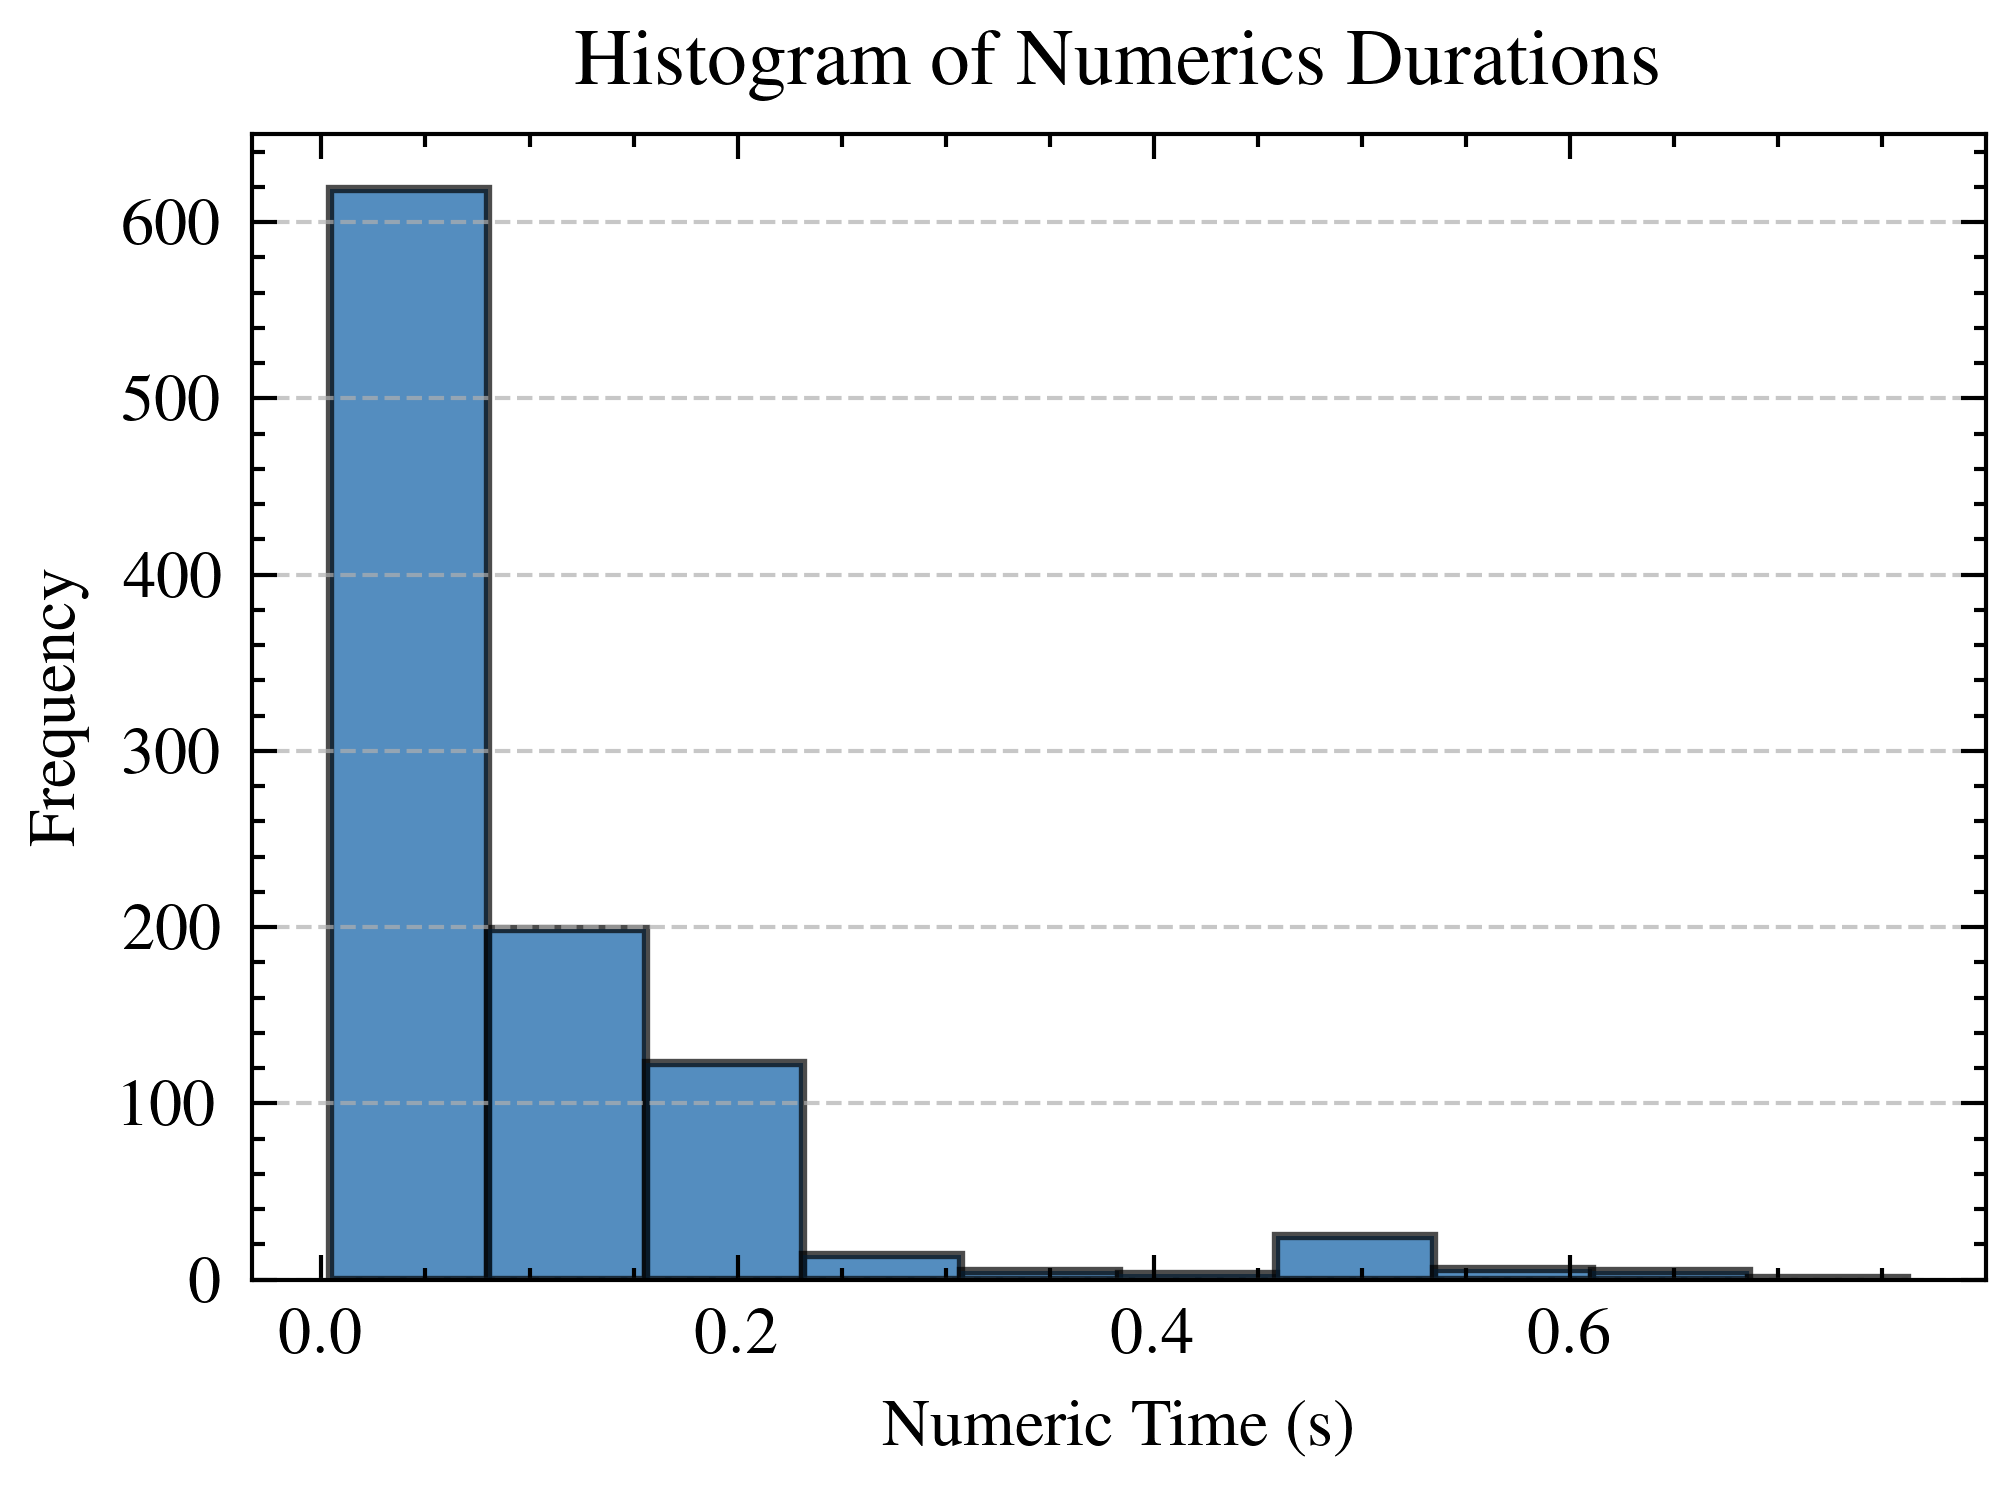

In [36]:
with plt.style.context(["ieee", "science", "use_mathtext"]):
    plt.hist(numeric_times, edgecolor="black", alpha=0.7)
    plt.xlabel("Numeric Time (s)")
    plt.ylabel("Frequency")
    plt.title("Histogram of Numerics Durations")
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()